In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.size"] = 11


In [2]:
positive_openers = [
    "The campus app", "This student platform", "The college service",
    "The ride sharing app", "The study dashboard", "The campus portal",
    "The attendance tracker", "The library app"
]

positive_features = [
    "is fast and reliable", "works smoothly every day", "has a clean interface",
    "makes college life easier", "saves me a lot of time", "is simple to use",
    "responds quickly", "keeps everything organized", "feels polished and useful",
    "helps me find what I need quickly"
]

positive_endings = [
    "I would use it again.", "I am very satisfied with it.",
    "The experience has been excellent.", "It is genuinely helpful.",
    "I recommend it to other students.", "It makes the whole process effortless."
]

negative_openers = [
    "The campus app", "This student platform", "The college service",
    "The ride sharing app", "The study dashboard", "The campus portal",
    "The attendance tracker", "The library app"
]

negative_features = [
    "is slow and unreliable", "crashes far too often", "has a confusing interface",
    "makes simple tasks difficult", "wastes a lot of my time", "is frustrating to use",
    "responds very slowly", "loses important information", "feels unfinished and buggy",
    "makes it hard to find what I need"
]

negative_endings = [
    "I would avoid it.", "I am very disappointed with it.",
    "The experience has been frustrating.", "It needs serious improvement.",
    "I would not recommend it to students.", "It makes routine tasks unnecessarily hard."
]

positive_rows = []
negative_rows = []

for i in range(20):
    positive_rows.extend(
        f"{positive_openers[i % len(positive_openers)]} {positive_features[(i * 3) % len(positive_features)]}. {positive_endings[(i * 2) % len(positive_endings)]}"
        for _ in range(3)
    )
    negative_rows.extend(
        f"{negative_openers[i % len(negative_openers)]} {negative_features[(i * 3) % len(negative_features)]}. {negative_endings[(i * 2) % len(negative_endings)]}"
        for _ in range(3)
    )

extra_positive = [
    "Finding a ride through the campus platform was quick and convenient.",
    "The notification system is accurate and saves me repeated checking.",
    "The timetable loads instantly and is easy to understand.",
    "Booking a study room took less than a minute.",
    "The interface looks modern and the navigation feels natural.",
    "The search results are relevant and appear immediately.",
    "Sharing a ride with classmates is now much more convenient.",
    "The dashboard gives me exactly the information I need.",
    "I can finish routine campus tasks without any hassle.",
    "The latest update made the app even smoother."
]

extra_negative = [
    "Finding a ride through the campus platform took forever.",
    "The notification system misses important updates.",
    "The timetable keeps loading and often shows stale information.",
    "Booking a study room is unnecessarily complicated.",
    "The interface looks cluttered and the navigation is confusing.",
    "The search results are slow and frequently irrelevant.",
    "Sharing a ride is difficult because requests fail repeatedly.",
    "The dashboard hides important information behind confusing menus.",
    "Routine campus tasks take far too many steps.",
    "The latest update introduced several annoying bugs."
]

positive_rows.extend(extra_positive * 4)
negative_rows.extend(extra_negative * 4)

texts = positive_rows + negative_rows
labels = [1] * len(positive_rows) + [0] * len(negative_rows)

df = pd.DataFrame({"review": texts, "sentiment": labels})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df["sentiment_name"] = df["sentiment"].map({0: "Negative", 1: "Positive"})

df.head(10)


,review,sentiment,sentiment_name
0,The search results are relevant and appear imm...,1,Positive
1,The campus portal is simple to use. I recommen...,1,Positive
2,The college service is fast and reliable. The ...,1,Positive
3,The ride sharing app loses important informati...,0,Negative
4,This student platform loses important informat...,0,Negative
5,The campus portal is frustrating to use. I wou...,0,Negative
6,The latest update made the app even smoother.,1,Positive
7,Finding a ride through the campus platform too...,0,Negative
8,The interface looks cluttered and the navigati...,0,Negative
9,The library app is simple to use. I would use ...,1,Positive


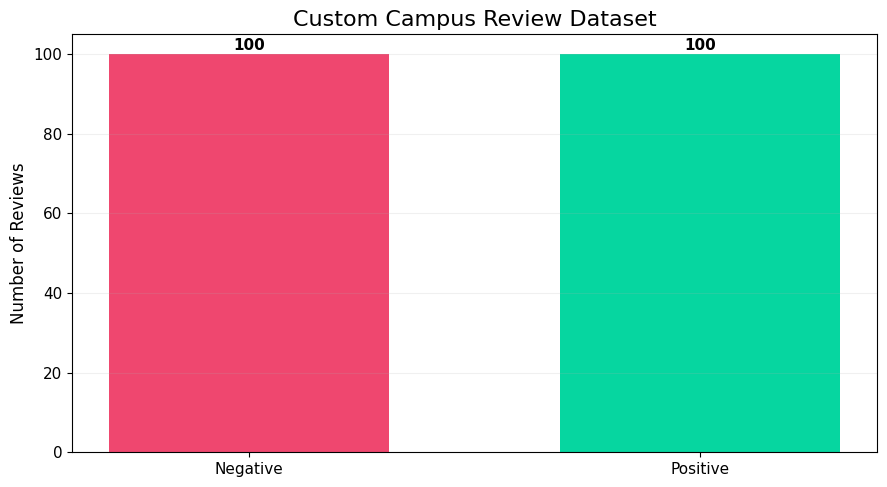

In [3]:
fig = plt.figure(figsize=(9, 5))
counts = df["sentiment_name"].value_counts().reindex(["Negative", "Positive"])
bars = plt.bar(counts.index, counts.values, color=["#ef476f", "#06d6a0"], width=0.62)
plt.title("Custom Campus Review Dataset")
plt.ylabel("Number of Reviews")
plt.grid(axis="y", alpha=0.18)
for bar, value in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, value + 1, str(value), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


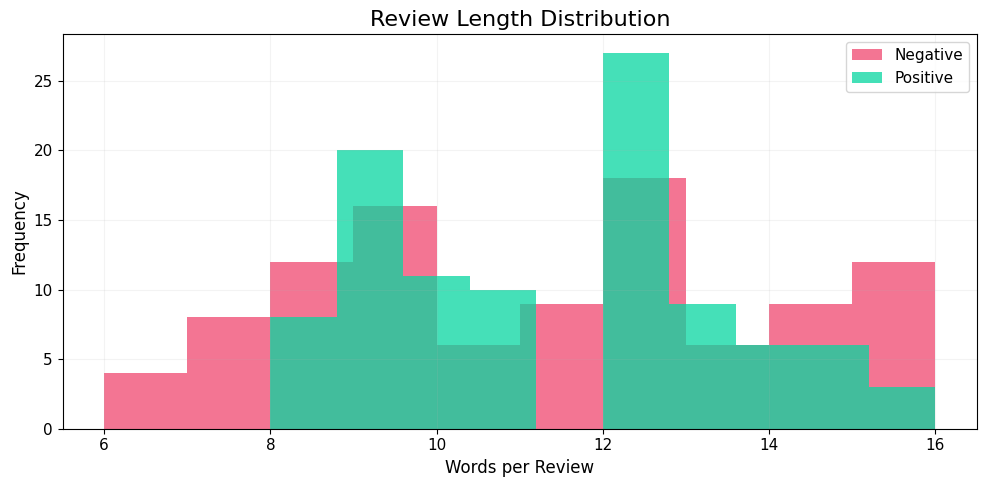

In [4]:
df["word_count"] = df["review"].str.split().str.len()

plt.figure(figsize=(10, 5))
plt.hist(df.loc[df.sentiment == 0, "word_count"], bins=10, alpha=0.75, color="#ef476f", label="Negative")
plt.hist(df.loc[df.sentiment == 1, "word_count"], bins=10, alpha=0.75, color="#06d6a0", label="Positive")
plt.title("Review Length Distribution")
plt.xlabel("Words per Review")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()


In [5]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["review"].values,
    df["sentiment"].values,
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment"].values
)

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_train_text,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

max_tokens = 2500
sequence_length = 30

vectorizer = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length,
    standardize="lower_and_strip_punctuation"
)

vectorizer.adapt(X_train_text)

vocab_size = len(vectorizer.get_vocabulary())

train_sequences = vectorizer(tf.constant(X_train_text))
val_sequences = vectorizer(tf.constant(X_val_text))
test_sequences = vectorizer(tf.constant(X_test_text))

print("Training samples:", len(X_train_text))
print("Validation samples:", len(X_val_text))
print("Test samples:", len(X_test_text))
print("Vocabulary size:", vocab_size)


Training samples: 128
Validation samples: 32
Test samples: 40
Vocabulary size: 157


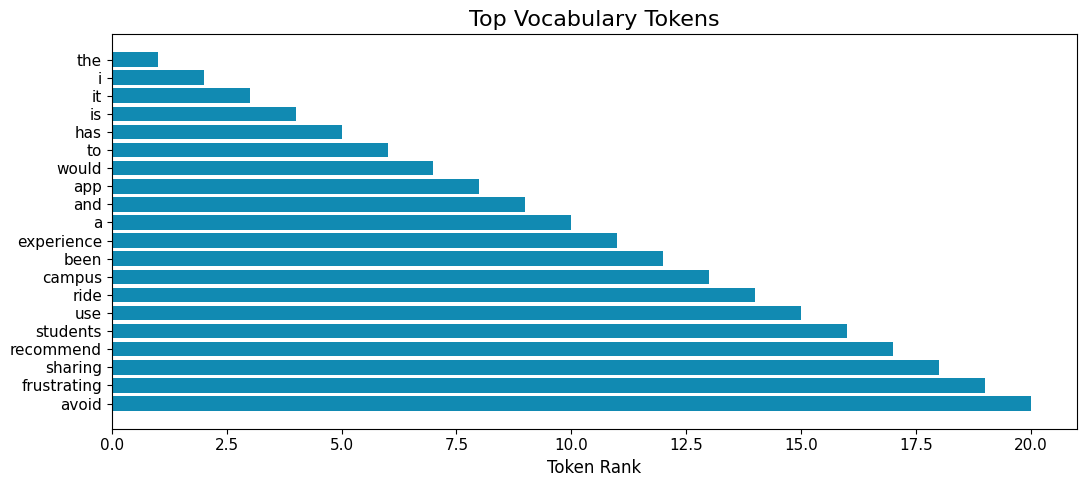

In [6]:
plt.figure(figsize=(11, 5))
sample = pd.Series(vectorizer.get_vocabulary()[2:22])
plt.barh(sample[::-1], np.arange(20)[::-1] + 1, color="#118ab2")
plt.title("Top Vocabulary Tokens")
plt.xlabel("Token Rank")
plt.tight_layout()
plt.show()


In [7]:
def build_unidirectional_rnn():
    model = models.Sequential([
        layers.Input(shape=(sequence_length,), dtype=tf.int64),
        layers.Embedding(vocab_size, 64),
        layers.SimpleRNN(32),
        layers.Dropout(0.25),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

def build_bidirectional_rnn():
    model = models.Sequential([
        layers.Input(shape=(sequence_length,), dtype=tf.int64),
        layers.Embedding(vocab_size, 64),
        layers.Bidirectional(layers.SimpleRNN(32)),
        layers.Dropout(0.25),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

uni_model = build_unidirectional_rnn()
bi_model = build_bidirectional_rnn()

uni_model.summary()
bi_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 64)         │        10,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 13,185 (51.50 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 30, 64)         │        10,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,321 (63.75 KB)

 Trainable params: 16,321 (63.75 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

uni_history = uni_model.fit(
    train_sequences,
    y_train,
    validation_data=(val_sequences, y_val),
    epochs=15,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

bi_history = bi_model.fit(
    train_sequences,
    y_train,
    validation_data=(val_sequences, y_val),
    epochs=15,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - accuracy: 0.5469 - loss: 0.6920 - val_accuracy: 0.6250 - val_loss: 0.6686
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8672 - loss: 0.5722 - val_accuracy: 0.5938 - val_loss: 0.6016
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9297 - loss: 0.3709 - val_accuracy: 0.7812 - val_loss: 0.5058
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9688 - loss: 0.1889 - val_accuracy: 0.8750 - val_loss: 0.3219
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9922 - loss: 0.1052 - val_accuracy: 0.9062 - val_loss: 0.2668
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9922 - loss: 0.0644 - val_accuracy: 0.9375 - val_loss: 0.2652
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0465 - val_accuracy: 0.9375 - val_loss: 0.2685
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0380 - val_accuracy: 0.9375 - val_loss: 0.2733

In [9]:
uni_test_loss, uni_test_acc = uni_model.evaluate(test_sequences, y_test, verbose=0)
bi_test_loss, bi_test_acc = bi_model.evaluate(test_sequences, y_test, verbose=0)

comparison = pd.DataFrame({
    "Model": ["Unidirectional RNN", "Bidirectional RNN"],
    "Test Loss": [uni_test_loss, bi_test_loss],
    "Test Accuracy": [uni_test_acc, bi_test_acc]
})

comparison


,Model,Test Loss,Test Accuracy
0,Unidirectional RNN,0.447918,0.875
1,Bidirectional RNN,0.663318,0.650


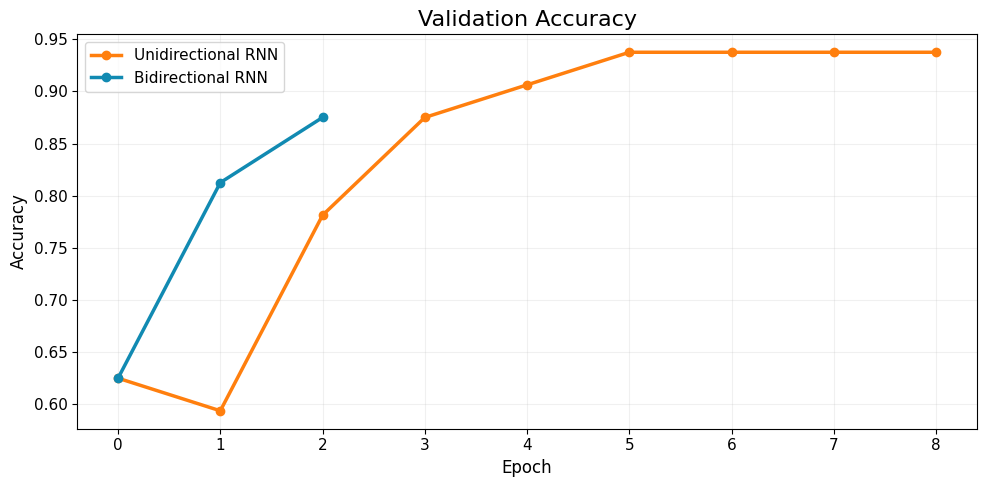

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(uni_history.history["val_accuracy"], marker="o", linewidth=2.5, color="#ff7f0e", label="Unidirectional RNN")
plt.plot(bi_history.history["val_accuracy"], marker="o", linewidth=2.5, color="#118ab2", label="Bidirectional RNN")
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.18)
plt.tight_layout()
plt.show()


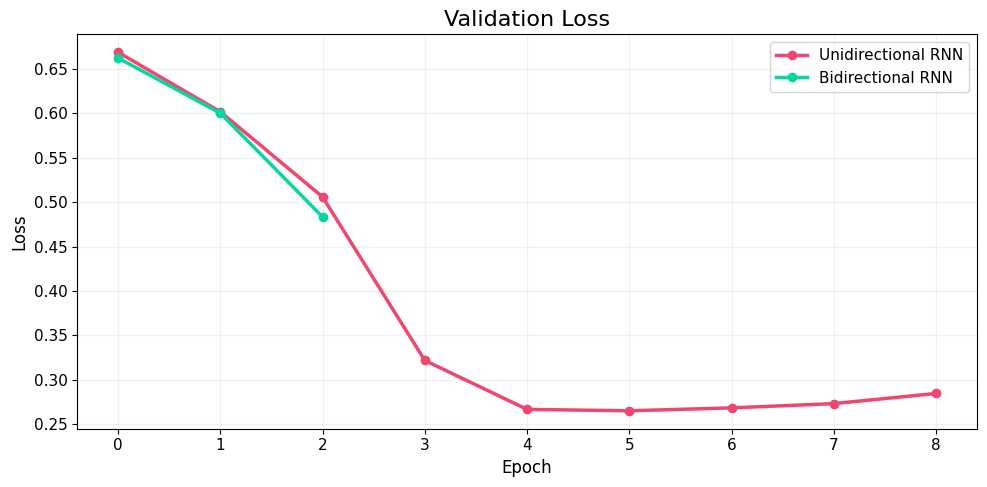

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(uni_history.history["val_loss"], marker="o", linewidth=2.5, color="#ef476f", label="Unidirectional RNN")
plt.plot(bi_history.history["val_loss"], marker="o", linewidth=2.5, color="#06d6a0", label="Bidirectional RNN")
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.18)
plt.tight_layout()
plt.show()


In [12]:
bi_pred_prob = bi_model.predict(test_sequences, verbose=0).ravel()
bi_pred = (bi_pred_prob >= 0.5).astype(int)

print(classification_report(
    y_test,
    bi_pred,
    target_names=["Negative", "Positive"],
    digits=4
))


              precision    recall  f1-score   support

    Negative     0.8000    0.4000    0.5333        20
    Positive     0.6000    0.9000    0.7200        20

    accuracy                         0.6500        40
   macro avg     0.7000    0.6500    0.6267        40
weighted avg     0.7000    0.6500    0.6267        40



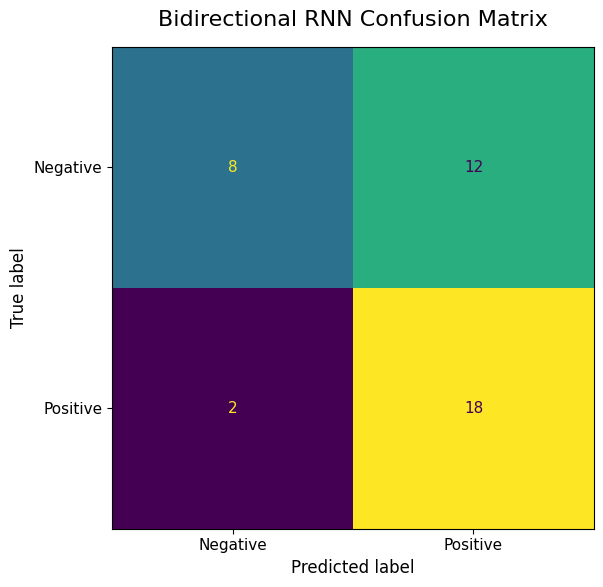

In [13]:
cm = confusion_matrix(y_test, bi_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="viridis", colorbar=False, values_format="d")
ax.set_title("Bidirectional RNN Confusion Matrix", pad=15)
plt.tight_layout()
plt.show()


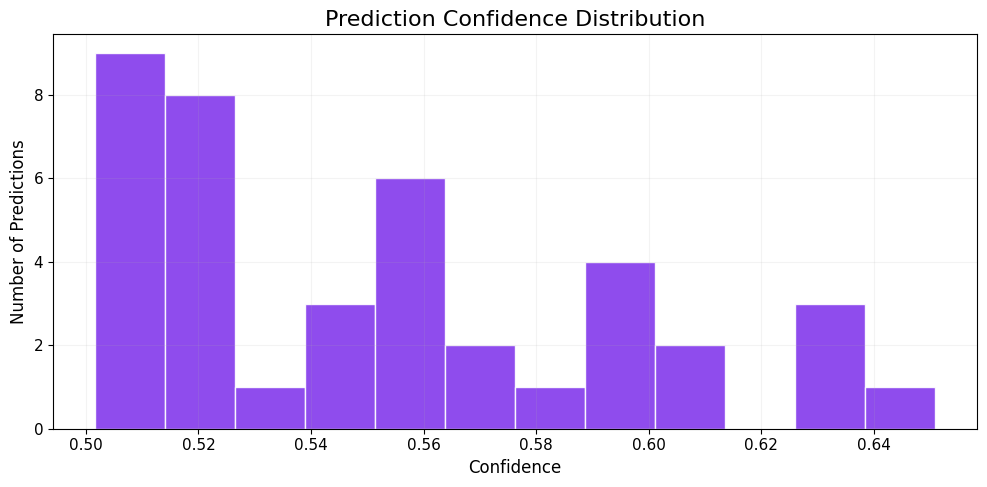

,Review,Actual,Predicted,Confidence,Correct
13,This student platform makes college life easie...,Positive,Positive,0.650895,True
28,The study dashboard has a clean interface. The...,Positive,Positive,0.638203,True
11,The notification system is accurate and saves ...,Positive,Positive,0.631538,True
24,The search results are relevant and appear imm...,Positive,Positive,0.630211,True
31,This student platform makes simple tasks diffi...,Negative,Positive,0.611766,False
38,The college service is fast and reliable. The ...,Positive,Positive,0.610172,True
23,I can finish routine campus tasks without any ...,Positive,Positive,0.600123,True
18,The ride sharing app loses important informati...,Negative,Positive,0.599930,False
3,The attendance tracker feels polished and usef...,Positive,Positive,0.590182,True
7,The campus portal is simple to use. I recommen...,Positive,Positive,0.589239,True


In [14]:
results = pd.DataFrame({
    "Review": X_test_text,
    "Actual": np.where(y_test == 1, "Positive", "Negative"),
    "Predicted": np.where(bi_pred == 1, "Positive", "Negative"),
    "Confidence": np.where(bi_pred == 1, bi_pred_prob, 1 - bi_pred_prob)
})

results["Correct"] = results["Actual"] == results["Predicted"]

plt.figure(figsize=(10, 5))
plt.hist(
    results["Confidence"],
    bins=12,
    color="#8338ec",
    edgecolor="white",
    alpha=0.9
)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Number of Predictions")
plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()

results.sort_values("Confidence", ascending=False).head(12)


In [15]:
def predict_sentiment(review):
    sequence = vectorizer(tf.constant([review]))
    probability = float(bi_model.predict(sequence, verbose=0)[0, 0])
    sentiment = "Positive" if probability >= 0.5 else "Negative"
    confidence = probability if probability >= 0.5 else 1 - probability
    return sentiment, confidence

custom_reviews = [
    "The campus portal is fast, clean, and very convenient.",
    "The app crashes constantly and wastes my time.",
    "The ride sharing feature makes finding classmates easy.",
    "The dashboard is confusing and difficult to navigate."
]

for review in custom_reviews:
    sentiment, confidence = predict_sentiment(review)
    print(f"{sentiment:>8} | {confidence:.2%} | {review}")


Positive | 55.34% | The campus portal is fast, clean, and very convenient.
Positive | 56.69% | The app crashes constantly and wastes my time.
Positive | 59.19% | The ride sharing feature makes finding classmates easy.
Positive | 55.87% | The dashboard is confusing and difficult to navigate.


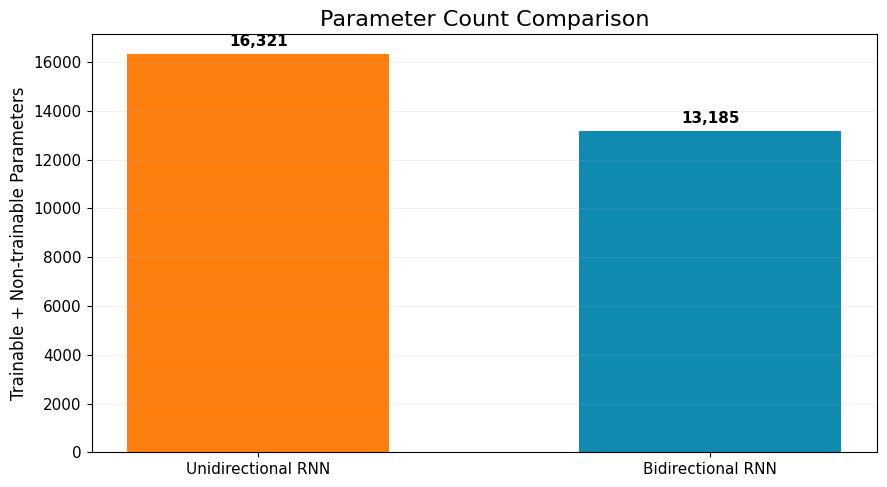

In [16]:
weights = bi_model.count_params(), uni_model.count_params()

plt.figure(figsize=(9, 5))
bars = plt.bar(
    ["Unidirectional RNN", "Bidirectional RNN"],
    weights,
    color=["#ff7f0e", "#118ab2"],
    width=0.58
)
plt.title("Parameter Count Comparison")
plt.ylabel("Trainable + Non-trainable Parameters")
plt.grid(axis="y", alpha=0.18)
for bar, value in zip(bars, weights):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + max(weights) * 0.02,
        f"{value:,}",
        ha="center",
        fontweight="bold"
    )
plt.tight_layout()
plt.show()


In [17]:
architecture_table = pd.DataFrame({
    "Feature": [
        "Direction",
        "RNN Cell",
        "Units per Direction",
        "Context",
        "Hidden Representation"
    ],
    "Unidirectional RNN": [
        "Left → Right",
        "SimpleRNN",
        32,
        "Past context",
        "32 features"
    ],
    "Bidirectional RNN": [
        "Left → Right + Right → Left",
        "SimpleRNN",
        32 + 32,
        "Past + future context",
        "64 features"
    ]
})

architecture_table


,Feature,Unidirectional RNN,Bidirectional RNN
0,Direction,Left → Right,Left → Right + Right → Left
1,RNN Cell,SimpleRNN,SimpleRNN
2,Units per Direction,32,64
3,Context,Past context,Past + future context
4,Hidden Representation,32 features,64 features


In [18]:
final_summary = pd.DataFrame({
    "Metric": [
        "Dataset size",
        "Vocabulary size",
        "Sequence length",
        "Unidirectional test accuracy",
        "Bidirectional test accuracy",
        "Unidirectional parameters",
        "Bidirectional parameters"
    ],
    "Value": [
        len(df),
        vocab_size,
        sequence_length,
        f"{uni_test_acc:.2%}",
        f"{bi_test_acc:.2%}",
        f"{uni_model.count_params():,}",
        f"{bi_model.count_params():,}"
    ]
})

final_summary


,Metric,Value
0,Dataset size,200
1,Vocabulary size,157
2,Sequence length,30
3,Unidirectional test accuracy,87.50%
4,Bidirectional test accuracy,65.00%
5,Unidirectional parameters,"13,185"
6,Bidirectional parameters,"16,321"
